In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
csv_path = "/content/drive/MyDrive/Assignment/data/Wednesday-workingHours.pcap_ISCX.csv"

df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print(df.head())
print("\nLabel distribution:")
print(df["Label"].value_counts())

Dataset shape: (692703, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0                80          38308                  1                       1   
1               389            479                 11                       5   
2                88           1095                 10                       6   
3               389          15206                 17                      12   
4                88           1092                  9                       6   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                            6                            6   
1                          172                          326   
2                         3150                         3150   
3                         3452                         6660   
4                         3150                         3152   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6       

In [5]:
dos_keywords = ["DoS", "DDoS"]

filtered_df = df[
    (df["Label"] == "BENIGN") |
    (df["Label"].str.contains("|".join(dos_keywords), case=False, na=False))
].copy()

print("Filtered shape:", filtered_df.shape)
print("\nFiltered label distribution:")
print(filtered_df["Label"].value_counts())

Filtered shape: (692692, 79)

Filtered label distribution:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


In [6]:
feature_df = filtered_df.drop(columns=["Label"]).copy()

feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.dropna(axis=0)

labels_clean = filtered_df.loc[feature_df.index, "Label"]

print("Clean feature shape:", feature_df.shape)
print("Clean label distribution:")
print(labels_clean.value_counts())

Clean feature shape: (691395, 78)
Clean label distribution:
Label
BENIGN              439683
DoS Hulk            230124
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


In [7]:
balanced_df = feature_df.copy()
balanced_df["Label"] = labels_clean.values

max_samples_per_class = 5000

sampled_parts = []

for label in balanced_df["Label"].unique():
    label_part = balanced_df[balanced_df["Label"] == label]
    sample_size = min(len(label_part), max_samples_per_class)
    sampled_part = label_part.sample(n=sample_size, random_state=seed)
    sampled_parts.append(sampled_part)

sampled_df = pd.concat(sampled_parts, axis=0).sample(frac=1, random_state=seed)

print("Sampled shape:", sampled_df.shape)
print("\nSampled label distribution:")
print(sampled_df["Label"].value_counts())

Sampled shape: (25000, 79)

Sampled label distribution:
Label
DoS slowloris       5000
DoS GoldenEye       5000
DoS Slowhttptest    5000
BENIGN              5000
DoS Hulk            5000
Name: count, dtype: int64


In [8]:
X = sampled_df.drop(columns=["Label"]).values.astype(np.float32)
y = sampled_df["Label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (25000, 78)


In [9]:
batch_size = 256

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = TensorDataset(X_tensor)

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

input_dim = X_scaled.shape[1]

print("Input feature dimension:", input_dim)

Input feature dimension: 78


In [10]:
class TrafficGenerator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class TrafficDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [11]:
def train_tabular_gan(
    generator,
    discriminator,
    train_loader,
    latent_dim=64,
    lr=0.0002,
    beta1=0.5,
    num_epochs=80,
    print_every=10
):
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    loss_function = nn.BCEWithLogitsLoss()

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

    g_losses = []
    d_losses = []

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for batch in train_loader:
            real_samples = batch[0].to(device)
            current_batch_size = real_samples.size(0)

            real_targets = torch.ones(current_batch_size, 1, device=device)
            fake_targets = torch.zeros(current_batch_size, 1, device=device)

            noise = torch.randn(current_batch_size, latent_dim, device=device)
            fake_samples = generator(noise)

            discriminator.zero_grad()

            real_outputs = discriminator(real_samples)
            fake_outputs = discriminator(fake_samples.detach())

            real_loss = loss_function(real_outputs, real_targets)
            fake_loss = loss_function(fake_outputs, fake_targets)
            d_loss = real_loss + fake_loss

            d_loss.backward()
            optimizer_d.step()

            noise = torch.randn(current_batch_size, latent_dim, device=device)
            fake_samples = generator(noise)

            generator.zero_grad()

            fake_outputs = discriminator(fake_samples)
            g_loss = loss_function(fake_outputs, real_targets)

            g_loss.backward()
            optimizer_g.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}] "
                f"Loss D: {avg_d_loss:.4f} | Loss G: {avg_g_loss:.4f}"
            )

    return generator, discriminator, g_losses, d_losses

In [12]:
latent_dim = 64

traffic_generator = TrafficGenerator(
    latent_dim=latent_dim,
    output_dim=input_dim
)

traffic_discriminator = TrafficDiscriminator(
    input_dim=input_dim
)

traffic_generator, traffic_discriminator, traffic_g_losses, traffic_d_losses = train_tabular_gan(
    generator=traffic_generator,
    discriminator=traffic_discriminator,
    train_loader=train_loader,
    latent_dim=latent_dim,
    lr=0.0002,
    beta1=0.5,
    num_epochs=80,
    print_every=10
)

Epoch [10/80] Loss D: 1.2439 | Loss G: 0.9229
Epoch [20/80] Loss D: 1.1694 | Loss G: 1.4126
Epoch [30/80] Loss D: 0.9595 | Loss G: 1.2503
Epoch [40/80] Loss D: 1.0883 | Loss G: 1.0832
Epoch [50/80] Loss D: 1.0084 | Loss G: 1.2068
Epoch [60/80] Loss D: 0.9441 | Loss G: 1.3309
Epoch [70/80] Loss D: 0.8178 | Loss G: 1.3876
Epoch [80/80] Loss D: 0.8739 | Loss G: 1.3372


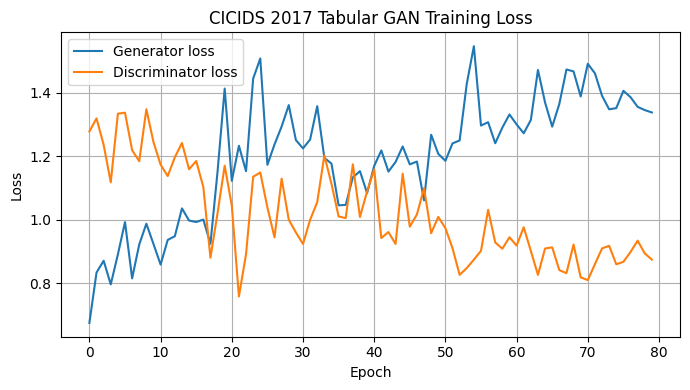

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(traffic_g_losses, label="Generator loss")
plt.plot(traffic_d_losses, label="Discriminator loss")
plt.title("CICIDS 2017 Tabular GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
traffic_generator.eval()

n_generated = min(5000, X_scaled.shape[0])

with torch.no_grad():
    noise = torch.randn(n_generated, latent_dim, device=device)
    generated_scaled = traffic_generator(noise).cpu().numpy()

generated_original_scale = scaler.inverse_transform(generated_scaled)

print("Generated scaled shape:", generated_scaled.shape)
print("Generated original-scale shape:", generated_original_scale.shape)

Generated scaled shape: (5000, 78)
Generated original-scale shape: (5000, 78)


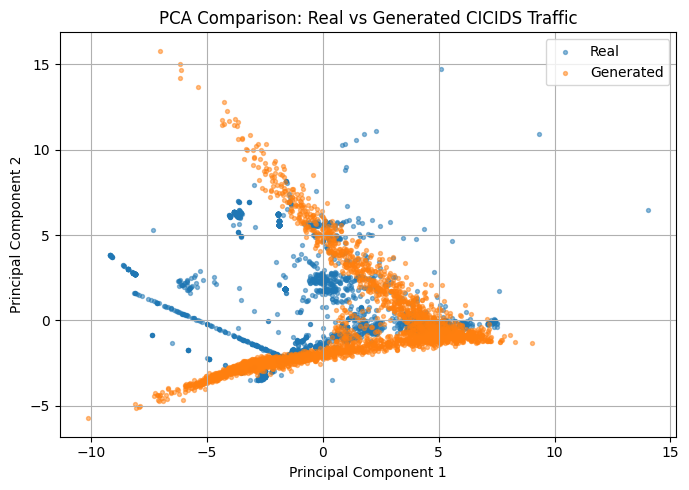

In [17]:
n_compare = min(3000, X_scaled.shape[0], generated_scaled.shape[0])

real_subset = X_scaled[:n_compare]
fake_subset = generated_scaled[:n_compare]

combined = np.vstack([real_subset, fake_subset])

pca = PCA(n_components=2, random_state=seed)
combined_pca = pca.fit_transform(combined)

real_pca = combined_pca[:n_compare]
fake_pca = combined_pca[n_compare:]

plt.figure(figsize=(7, 5))
plt.scatter(real_pca[:, 0], real_pca[:, 1], s=8, alpha=0.5, label="Real")
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=8, alpha=0.5, label="Generated")
plt.title("PCA Comparison: Real vs Generated CICIDS Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
real_mean = real_subset.mean(axis=0)
fake_mean = fake_subset.mean(axis=0)

real_std = real_subset.std(axis=0)
fake_std = fake_subset.std(axis=0)

mean_abs_error = np.mean(np.abs(real_mean - fake_mean))
std_abs_error = np.mean(np.abs(real_std - fake_std))

print(f"Mean absolute difference between feature means: {mean_abs_error:.4f}")
print(f"Mean absolute difference between feature std values: {std_abs_error:.4f}")

Mean absolute difference between feature means: 0.2149
Mean absolute difference between feature std values: 0.4077
